In [25]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

CUBE_PATH = Path(r"C:\Users\achun\manga-data-pipeline\data\manga-11019-12701-LOGCUBE.fits")

hdul = fits.open(CUBE_PATH)
hdul.info()

Filename: C:\Users\achun\manga-data-pipeline\data\manga-11019-12701-LOGCUBE.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      75   ()      
  1  FLUX          1 ImageHDU       100   (72, 72, 4563)   float32   
  2  IVAR          1 ImageHDU        17   (72, 72, 4563)   float32   
  3  MASK          1 ImageHDU        17   (72, 72, 4563)   int32   
  4  LSFPOST       1 ImageHDU        11   (72, 72, 4563)   float32   
  5  LSFPRE        1 ImageHDU        11   (72, 72, 4563)   float32   
  6  WAVE          1 ImageHDU         9   (4563,)   float64   
  7  SPECRES       1 ImageHDU         9   (4563,)   float64   
  8  SPECRESD      1 ImageHDU         9   (4563,)   float64   
  9  PRESPECRES    1 ImageHDU         9   (4563,)   float64   
 10  PRESPECRESD    1 ImageHDU         9   (4563,)   float64   
 11  OBSINFO       1 BinTableHDU    148   9R x 65C   [26A, 17A, 5A, J, I, 8A, E, E, E, E, E, E, J, J, I, J, E, 12A, J, 8A, E, E, E, E, E, E, E

In [26]:
# MaNGA LOGCUBE HDUs: FLUX (nw, ny, nx), IVAR, MASK, WAVE (nw,)
flux = hdul["FLUX"].data
ivar = hdul["IVAR"].data
mask = hdul["MASK"].data
wave = hdul["WAVE"].data

flux_header = hdul["FLUX"].header
print(f"FLUX shape: {flux.shape}  (wavelength, y, x)")
print(f"WAVE range: {wave[0]:.2f} – {wave[-1]:.2f} {flux_header.get('CUNIT3', 'Angstrom')}")
print(f"Units: {flux_header.get('BUNIT', 'unknown')}")

FLUX shape: (4563, 72, 72)  (wavelength, y, x)
WAVE range: 3621.60 – 10353.81 Angstrom
Units: 1E-17 erg/s/cm^2/Angstrom/spaxel


In [27]:
# Slice FLUX along wavelength (axis 0) for 6560–6564 Å
wave_lo, wave_hi = 6560.0, 6564.0
wave_slice = (wave >= wave_lo) & (wave <= wave_hi)
flux_halpha = flux[wave_slice]
wave_halpha = wave[wave_slice]

print(f"selected channels: {wave_slice.sum()}")
print(f"WAVE in window: {wave_halpha}")
print(f"flux_halpha shape: {flux_halpha.shape}  (nw_slice, y, x)")

selected channels: 2
WAVE in window: [6561.45266303 6562.96366729]
flux_halpha shape: (2, 72, 72)  (nw_slice, y, x)


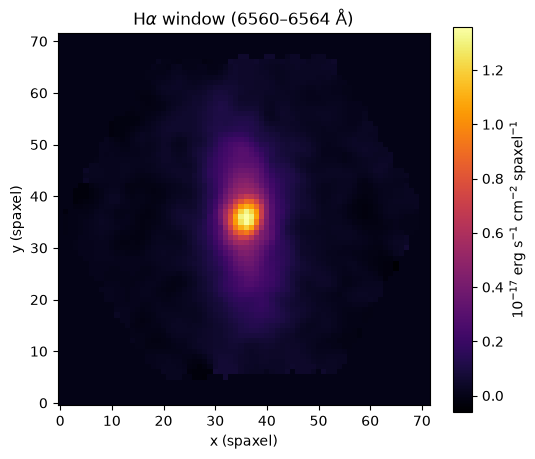

In [28]:
halpha_map = np.sum(flux_halpha, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(halpha_map, origin="lower", cmap="inferno")
ax.set_title(r"H$\alpha$ window (6560–6564 Å)")
ax.set_xlabel("x (spaxel)")
ax.set_ylabel("y (spaxel)")
fig.colorbar(im, ax=ax, label=r"$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ spaxel$^{-1}$")
plt.show()

In [29]:
# [O II] 3726–3729 Å; MASK != 0 means the voxel should not be used
oii_slice = (wave >= 3726.0) & (wave <= 3729.0)
flux_oii = np.where(mask[oii_slice] == 0, flux[oii_slice], 0)
wave_oii = wave[oii_slice]

# [N II] 6582–6586 Å
nii_slice = (wave >= 6582.0) & (wave <= 6586.0)
flux_nii = np.where(mask[nii_slice] == 0, flux[nii_slice], 0)
wave_nii = wave[nii_slice]

print(f"flux_oii channels: {oii_slice.sum()}  WAVE: {wave_oii}  shape: {flux_oii.shape}")
print(f"flux_nii channels: {nii_slice.sum()}  WAVE: {wave_nii}  shape: {flux_nii.shape}")
print(f"masked OII voxels: {(mask[oii_slice] != 0).sum()}  masked NII voxels: {(mask[nii_slice] != 0).sum()}")

flux_oii channels: 3  WAVE: [3726.490342   3727.3484969  3728.20684943]  shape: (3, 72, 72)
flux_nii channels: 3  WAVE: [6582.63841641 6584.15429943 6585.67053154]  shape: (3, 72, 72)
masked OII voxels: 7200  masked NII voxels: 7215


In [30]:
oii_map = np.sum(flux_oii, axis=0)
nii_map = np.sum(flux_nii, axis=0)

with np.errstate(divide="ignore", invalid="ignore"):
    R = np.log(nii_map / oii_map)
# spaxels with zero/negative flux give inf as well as nan
R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)

print(f"oii_map shape: {oii_map.shape}")
print(f"nii_map shape: {nii_map.shape}")
print(f"R shape: {R.shape}  finite: {np.isfinite(R).sum()}/{R.size}")

oii_map shape: (72, 72)
nii_map shape: (72, 72)
R shape: (72, 72)  finite: 5184/5184


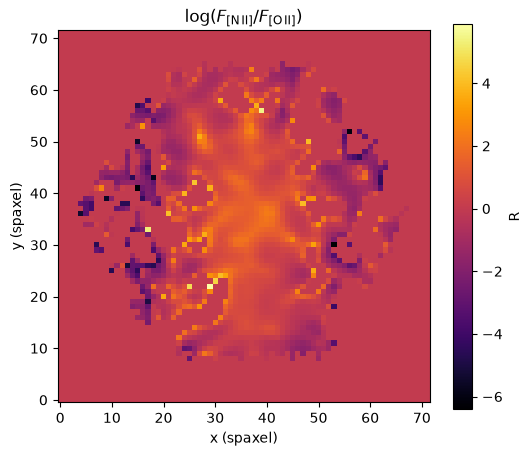

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, origin="lower", cmap="inferno")
ax.set_title(r"$\log(F_{\mathrm{[N\,II]}} / F_{\mathrm{[O\,II]}})$")
ax.set_xlabel("x (spaxel)")
ax.set_ylabel("y (spaxel)")
fig.colorbar(im, ax=ax, label="R")
plt.show()

In [32]:
# Kewley & Dopita (2002) N2O2 calibration: 12 + log(O/H)
with np.errstate(invalid="ignore"):
    OH = np.log(1.54020 + 1.26602 * R + 0.167977 * R**2) + 8.93
OH = np.nan_to_num(OH, nan=0.0, posinf=0.0, neginf=0.0)

# MASK is (nw, ny, nx); flag a spaxel if any [O II] or [N II] voxel is masked
spaxel_masked = np.any(mask[oii_slice] != 0, axis=0) | np.any(mask[nii_slice] != 0, axis=0)
OH = np.where(spaxel_masked, 0, OH)

print(f"OH shape: {OH.shape}  finite: {np.isfinite(OH).sum()}/{OH.size}")
print(f"masked spaxels: {spaxel_masked.sum()}")

OH shape: (72, 72)  finite: 5184/5184
masked spaxels: 2470


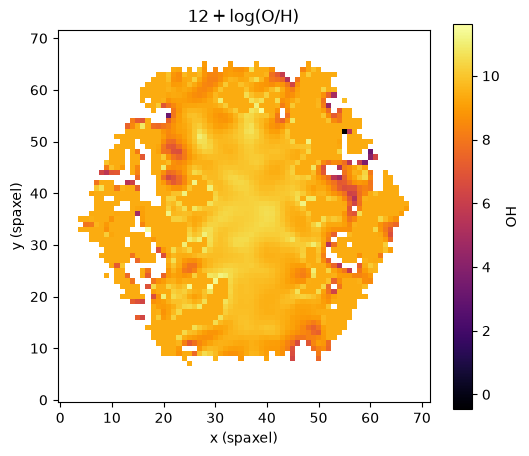

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.ma.masked_where(OH == 0, OH), origin="lower", cmap="inferno")
ax.set_title(r"$12 + \log(\mathrm{O/H})$")
ax.set_xlabel("x (spaxel)")
ax.set_ylabel("y (spaxel)")
fig.colorbar(im, ax=ax, label="OH")
plt.show()